# Revisão de Álgebra Linear: Matrizes 

Material baseado no capítulo **Chapter 5: Matrices, Part 1**.

Neste notebook exploramos os fundamentos de matrizes na teoria e na prática computacional:
1. Criação, indexação, fatiamento (*slicing*) e visualização com `seaborn`.
2. Matrizes especiais (identidade, diagonais, triangulares, nulas e aleatórias).
3. Operações aritméticas elementares, deslocamento (*shifting*) e produto de Hadamard.
4. Multiplicação padrão de matrizes e multiplicação matriz-vetor (transformações geométricas).
5. Transposição, a regra mnemônica **LIVE EVIL** e matrizes simétricas ($A^T A$ e $A A^T$).

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações estéticas globais para o seaborn
sns.set_theme(style="white")

--- 
## 1. O que é uma Matriz? Indexação e Visualização com Seaborn

### Teoria
Uma matriz é uma tabela bidimensional ordenada de números organizada em $M$ linhas e $N$ colunas ($A \in \mathbb{R}^{M \times N}$).

* Na matemática convencional, a indexação começa em 1: $a_{i,j}$ é o elemento na linha $i$ e coluna $j$.
* Em Python (NumPy), a indexação começa em 0: o elemento $a_{i,j}$ é acessado como `A[i-1, j-1]`.

Matrizes com muitos elementos podem ser visualizadas como imagens ou mapas de calor (*heatmaps*), onde a cor codifica a intensidade numérica de cada célula.

Matriz original A (shape): (6, 10)
Elemento A[2, 3] (3ª linha, 4ª coluna no math): 23

Submatriz extraída:
 [[10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]


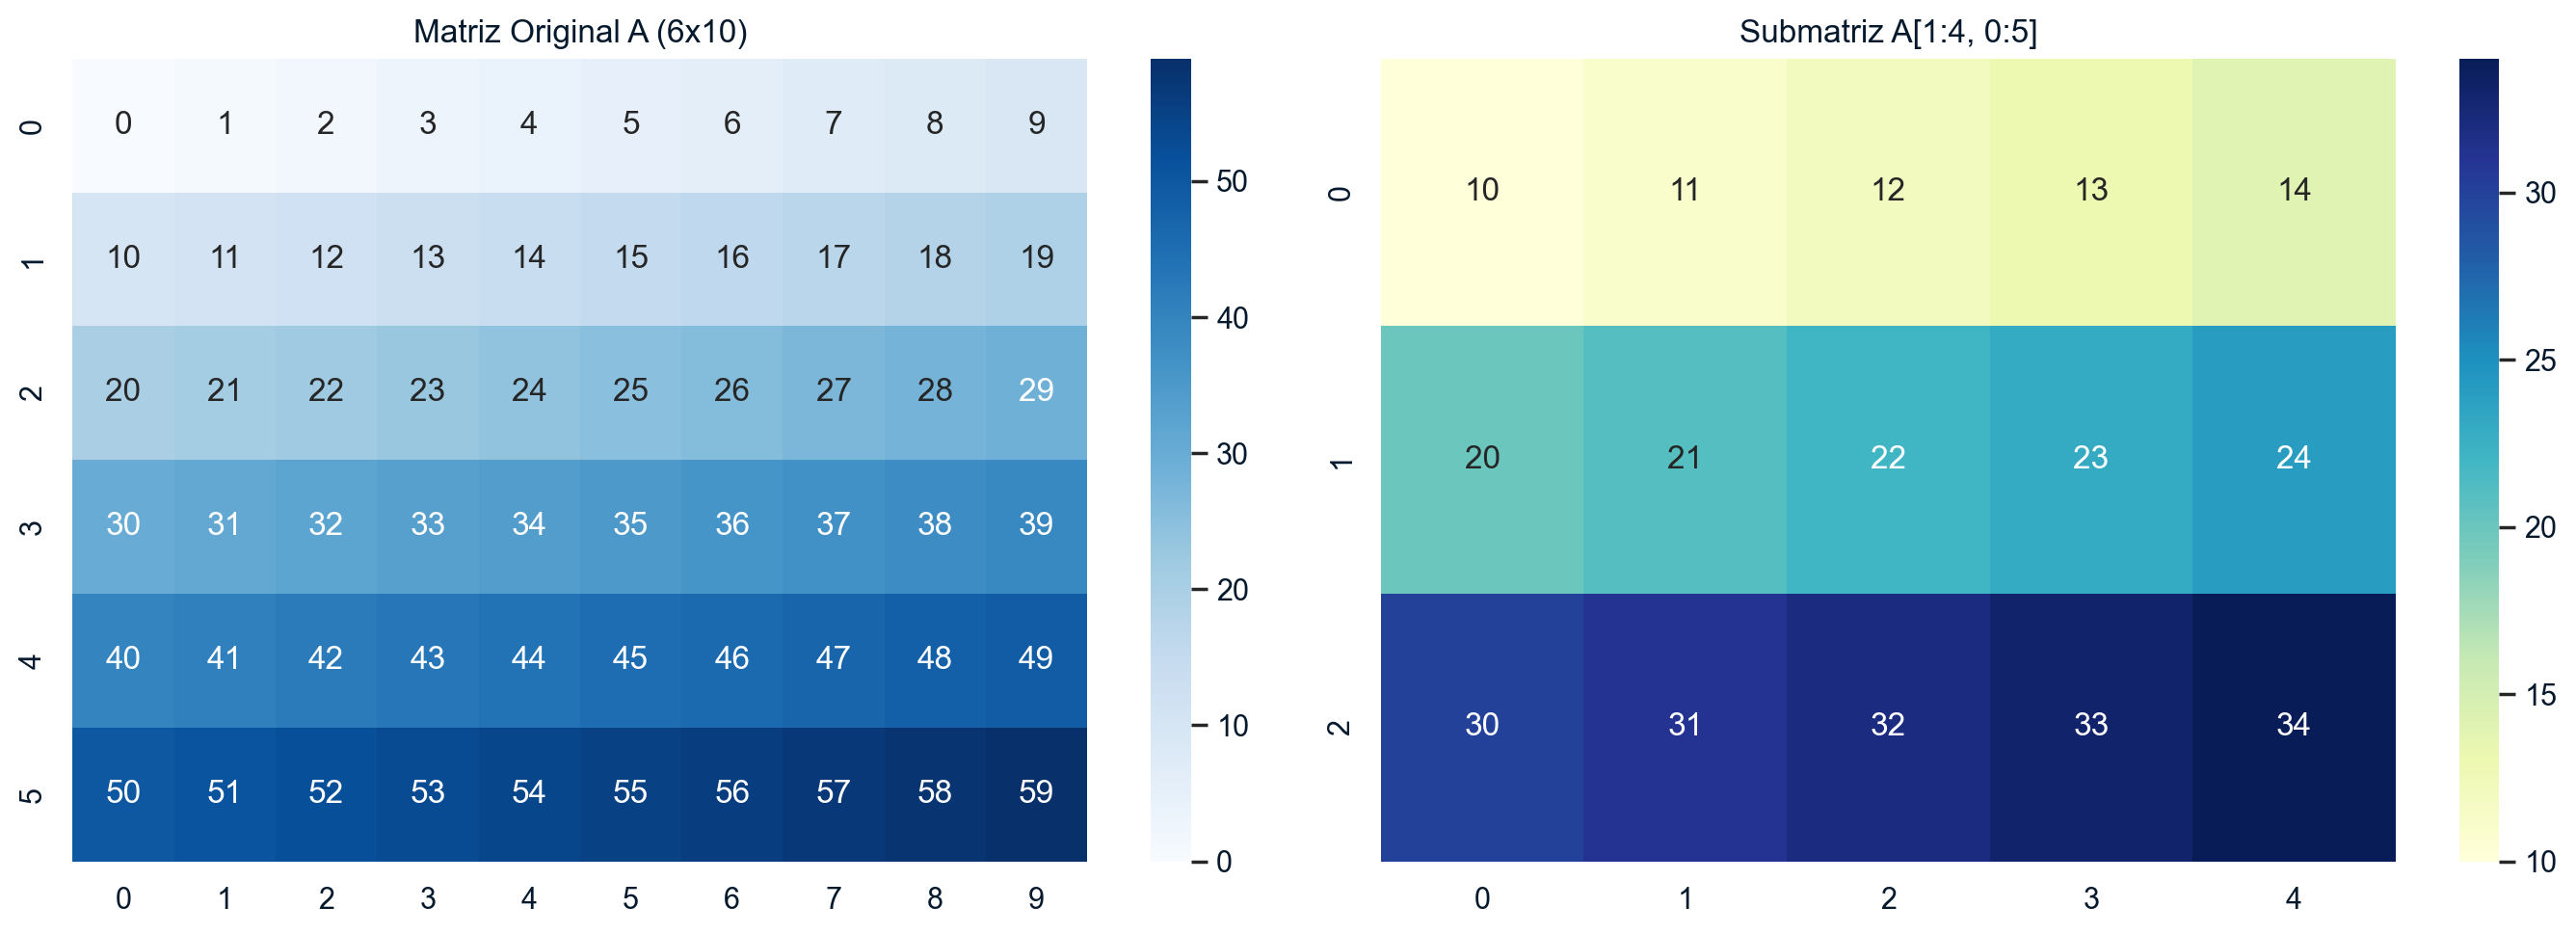

In [18]:
# Criando uma matriz 6x10 com valores de 0 a 59
A = np.arange(60).reshape(6, 10)

# Fatiamento (slicing): linhas 1 a 3 (índices 1:4) e colunas 0 a 4 (índices 0:5)
sub_A = A[1:4, 0:5]

print("Matriz original A (shape):", A.shape)
print("Elemento A[2, 3] (3ª linha, 4ª coluna no math):", A[2, 3])
print("\nSubmatriz extraída:\n", sub_A)

# Visualizando com Seaborn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(A, annot=True, fmt="d", cmap="Blues", cbar=True, ax=axes[0])
axes[0].set_title("Matriz Original A (6x10)")

sns.heatmap(sub_A, annot=True, fmt="d", cmap="YlGnBu", cbar=True, ax=axes[1])
axes[1].set_title("Submatriz A[1:4, 0:5]")

plt.tight_layout()
plt.show()

--- 
## 2. Famílias de Matrizes Especiais

Existem padrões estruturais frequentes em álgebra linear:
* **Matriz Quadrada:** $M = N$.
* **Matriz Retangular:** $M \neq N$ (pode ser *tall* se $M > N$ ou *wide* se $N > M$).
* **Diagonal:** Valores fora da diagonal principal são estritamente nulos (`np.diag`).
* **Triangular:** Todos os valores acima (*lower triangular*, `np.tril`) ou abaixo (*upper triangular*, `np.triu`) da diagonal são zero.
* **Identidade ($I$):** Matriz diagonal quadrada com 1s na diagonal principal (`np.eye`). Atua como o elemento neutro da multiplicação.
* **Matriz Nula ($\mathbf{0}$):** Todos os elementos são 0 (`np.zeros`).

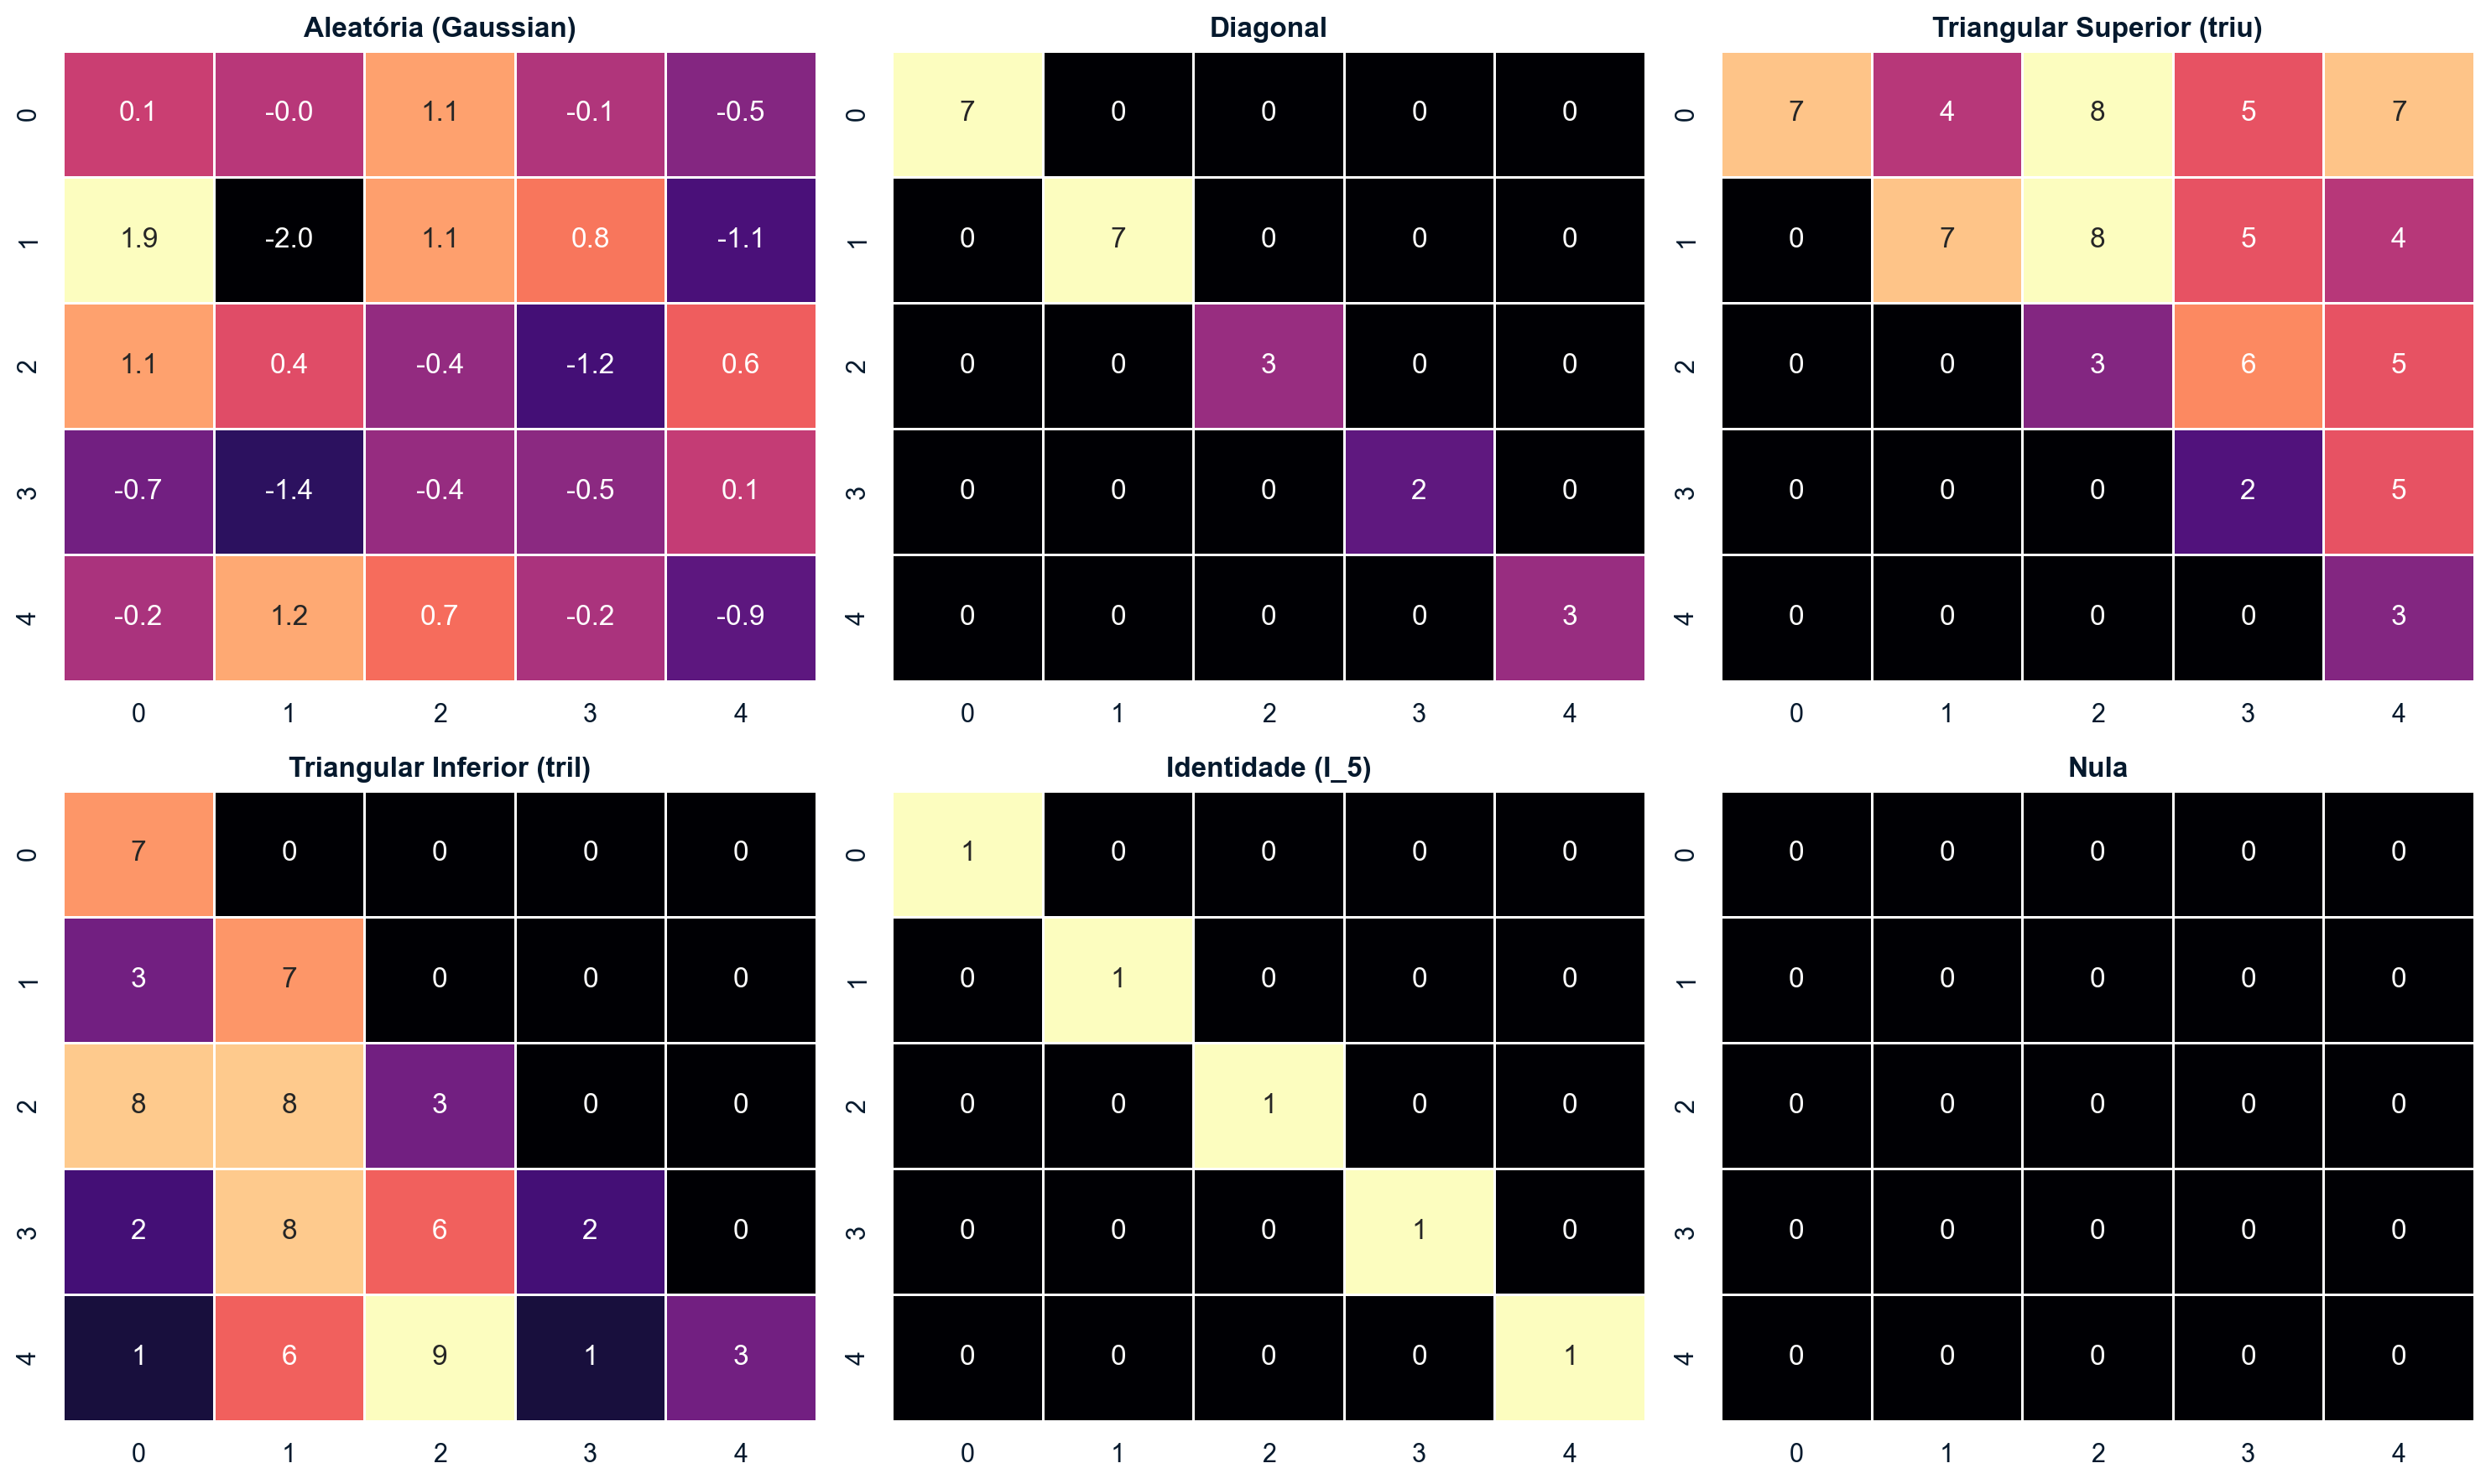

In [19]:
np.random.seed(42)
base_mat = np.random.randint(1, 10, size=(5, 5))

matrices = {
    "Aleatória (Gaussian)": np.random.randn(5, 5),
    "Diagonal": np.diag(np.diag(base_mat)),
    "Triangular Superior (triu)": np.triu(base_mat),
    "Triangular Inferior (tril)": np.tril(base_mat),
    "Identidade (I_5)": np.eye(5),
    "Nula": np.zeros((5, 5))
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (title, mat) in zip(axes, matrices.items()):
    sns.heatmap(mat, annot=True, fmt=".1f" if "Aleatória" in title else ".0f", 
                cmap="magma", cbar=False, ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

--- 
## 3. Aritmética Matricial, Deslocamento (*Shifting*) e Produto de Hadamard

### Adição e Subtração
Definidas apenas para matrizes de mesmas dimensões e executadas elemento a elemento.

### Deslocamento (*Shifting*)
Somar um escalar a uma matriz não é formalmente definido na álgebra linear. Para injetar uma constante de regularização preservando a álgebra, realiza-se o **shifting** somando um múltiplo da matriz identidade:

$$A_{\text{shifted}} = A + \lambda I$$

Essa operação altera unicamente a diagonal principal, sendo o núcleo do cálculo de autovalores e da regularização estatística (ex: regressão Ridge/Tikhonov).

### Multiplicação de Hadamard
Multiplicação elemento a elemento representada por $\odot$. No NumPy é feita com o operador `*` ou `np.multiply()`.

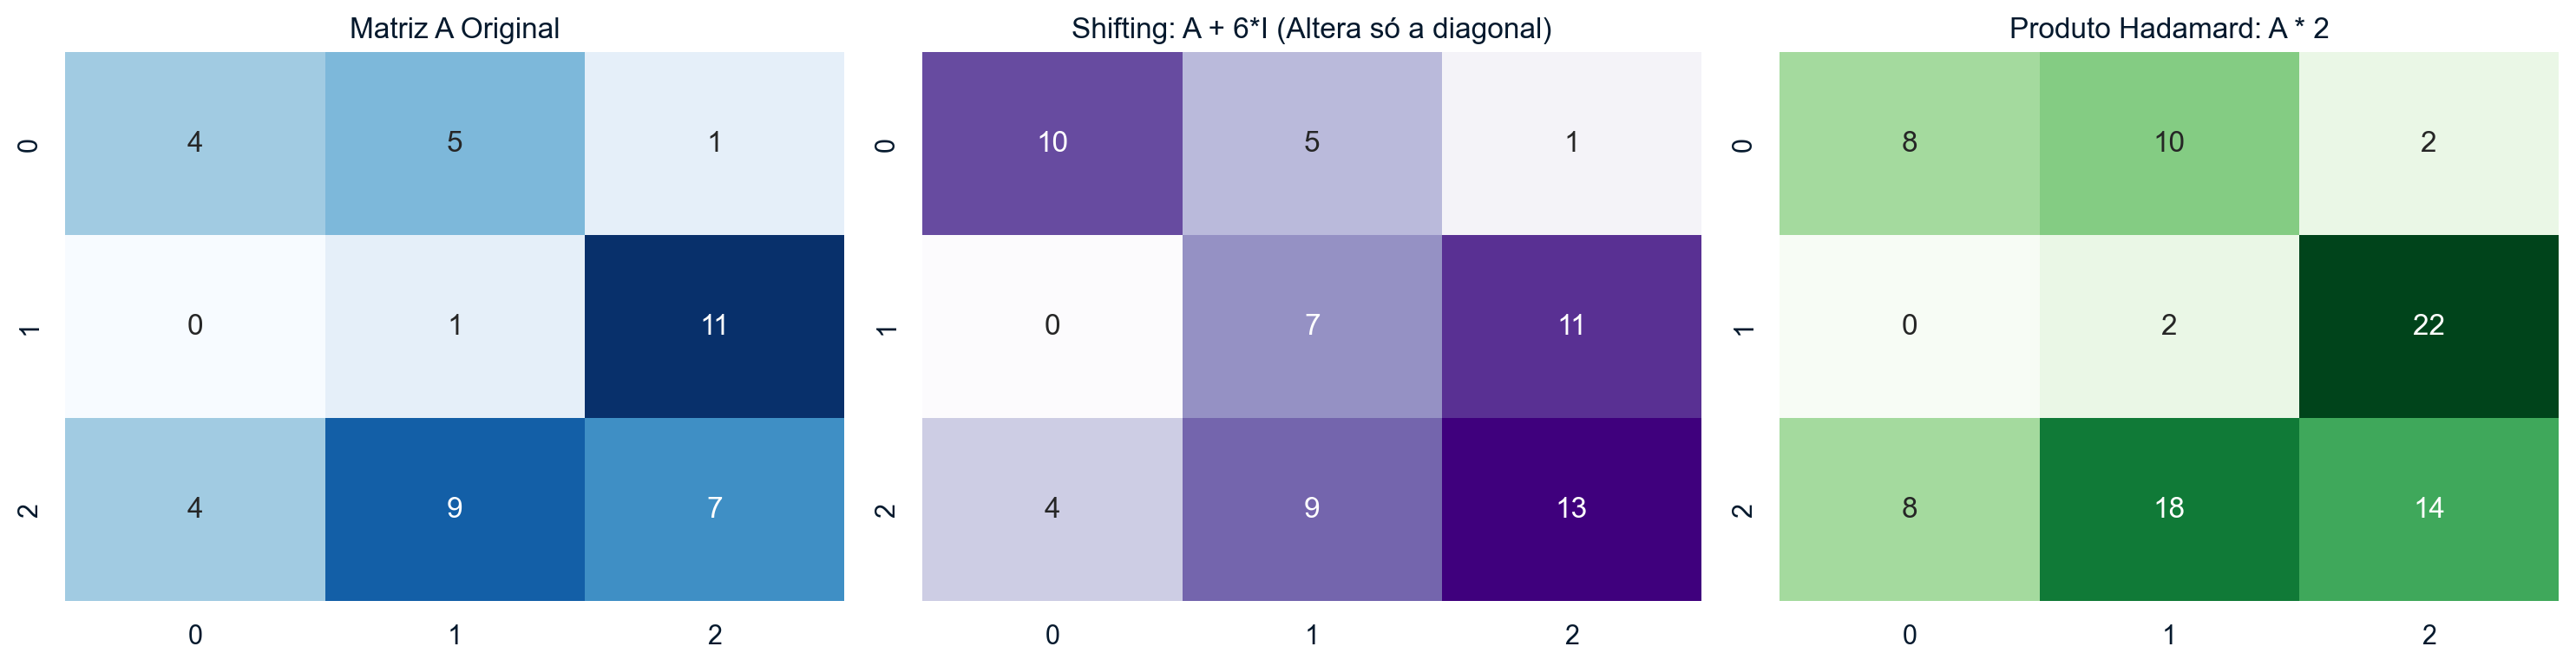

In [20]:
A = np.array([[4, 5, 1], 
              [0, 1, 11], 
              [4, 9, 7]], dtype=float)

s = 6.0
# Shifting formal: A + s*I
A_shifted = A + s * np.eye(len(A))

# Hadamard com outra matriz
B = np.ones((3, 3)) * 2
A_hadamard = A * B

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(A, annot=True, fmt=".0f", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Matriz A Original")

sns.heatmap(A_shifted, annot=True, fmt=".0f", cmap="Purples", ax=axes[1], cbar=False)
axes[1].set_title(f"Shifting: A + {int(s)}*I (Altera só a diagonal)")

sns.heatmap(A_hadamard, annot=True, fmt=".0f", cmap="Greens", ax=axes[2], cbar=False)
axes[2].set_title("Produto Hadamard: A * 2")

plt.tight_layout()
plt.show()

--- 
## 4. Multiplicação Padrão de Matrizes

### Condição de Existência
Para multiplicar $A \in \mathbb{R}^{M \times N}$ por $B \in \mathbb{R}^{N \times K}$, a dimensão interna precisa ser idêntica ($N = N$). O produto resultante terá as dimensões externas: $C = AB \in \mathbb{R}^{M \times K}$.

$$c_{i,j} = \sum_{k=1}^N a_{i,k} b_{k,j} = \text{linha}_i(A) \cdot \text{coluna}_j(B)$$

Em Python, a multiplicação padrão utiliza o operador `@` (ou `np.matmul()`). Ela **não é comutativa** ($AB \neq BA$ em geral).

Dimensões: A(2, 2) @ B(2, 3) = C(2, 3)


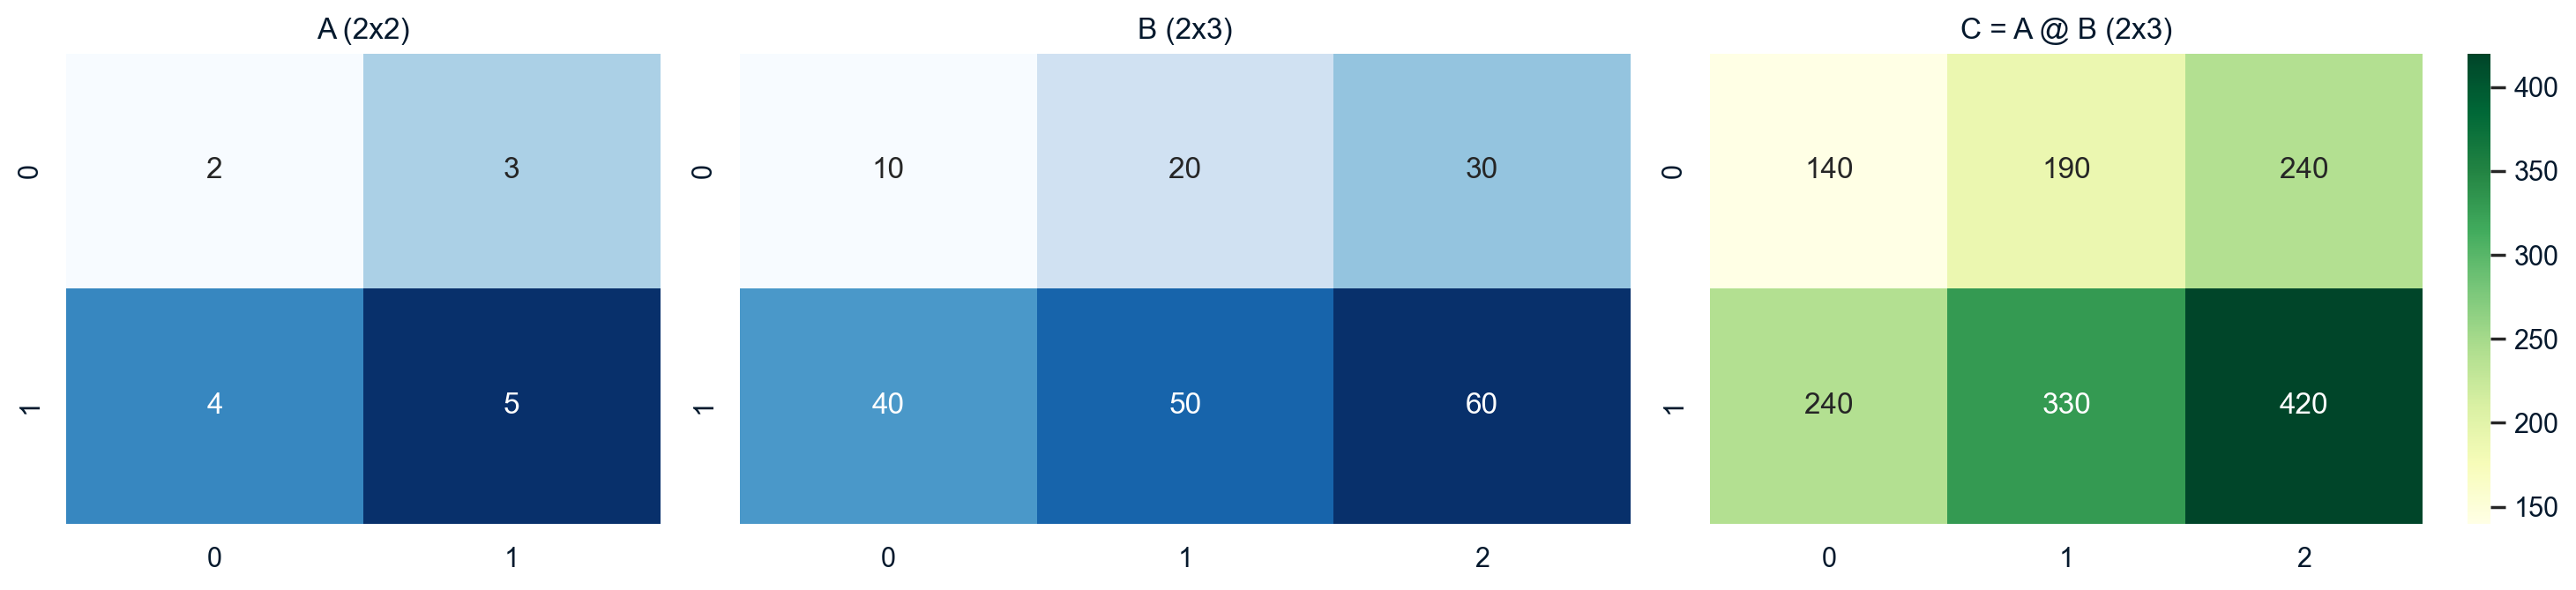

In [21]:
A = np.array([[2, 3],
              [4, 5]])  # 2x2

B = np.array([[10, 20, 30],
              [40, 50, 60]])  # 2x3

# Multiplicação padrão: (2x2) @ (2x3) -> (2x3)
C = A @ B

print(f"Dimensões: A{A.shape} @ B{B.shape} = C{C.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), gridspec_kw={'width_ratios': [2, 3, 3]})
sns.heatmap(A, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("A (2x2)")

sns.heatmap(B, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("B (2x3)")

sns.heatmap(C, annot=True, fmt="d", cmap="YlGn", cbar=True, ax=axes[2])
axes[2].set_title("C = A @ B (2x3)")

plt.tight_layout()
plt.show()

--- 
## 5. Multiplicação Matriz-Vetor: Transformações Geométricas

Multiplicar uma matriz por um vetor coluna transforma geometricamente o espaço, rotacionando e escalonando o vetor ($w = Mv$).

Quando um vetor tem sua orientação inalterada (apenas sofre escalonamento), ele é chamado de **autovetor** (*eigenvector*) da matriz, e o fator de escala é o seu **autovalor** (*eigenvalue*): $Mv = \lambda v$.

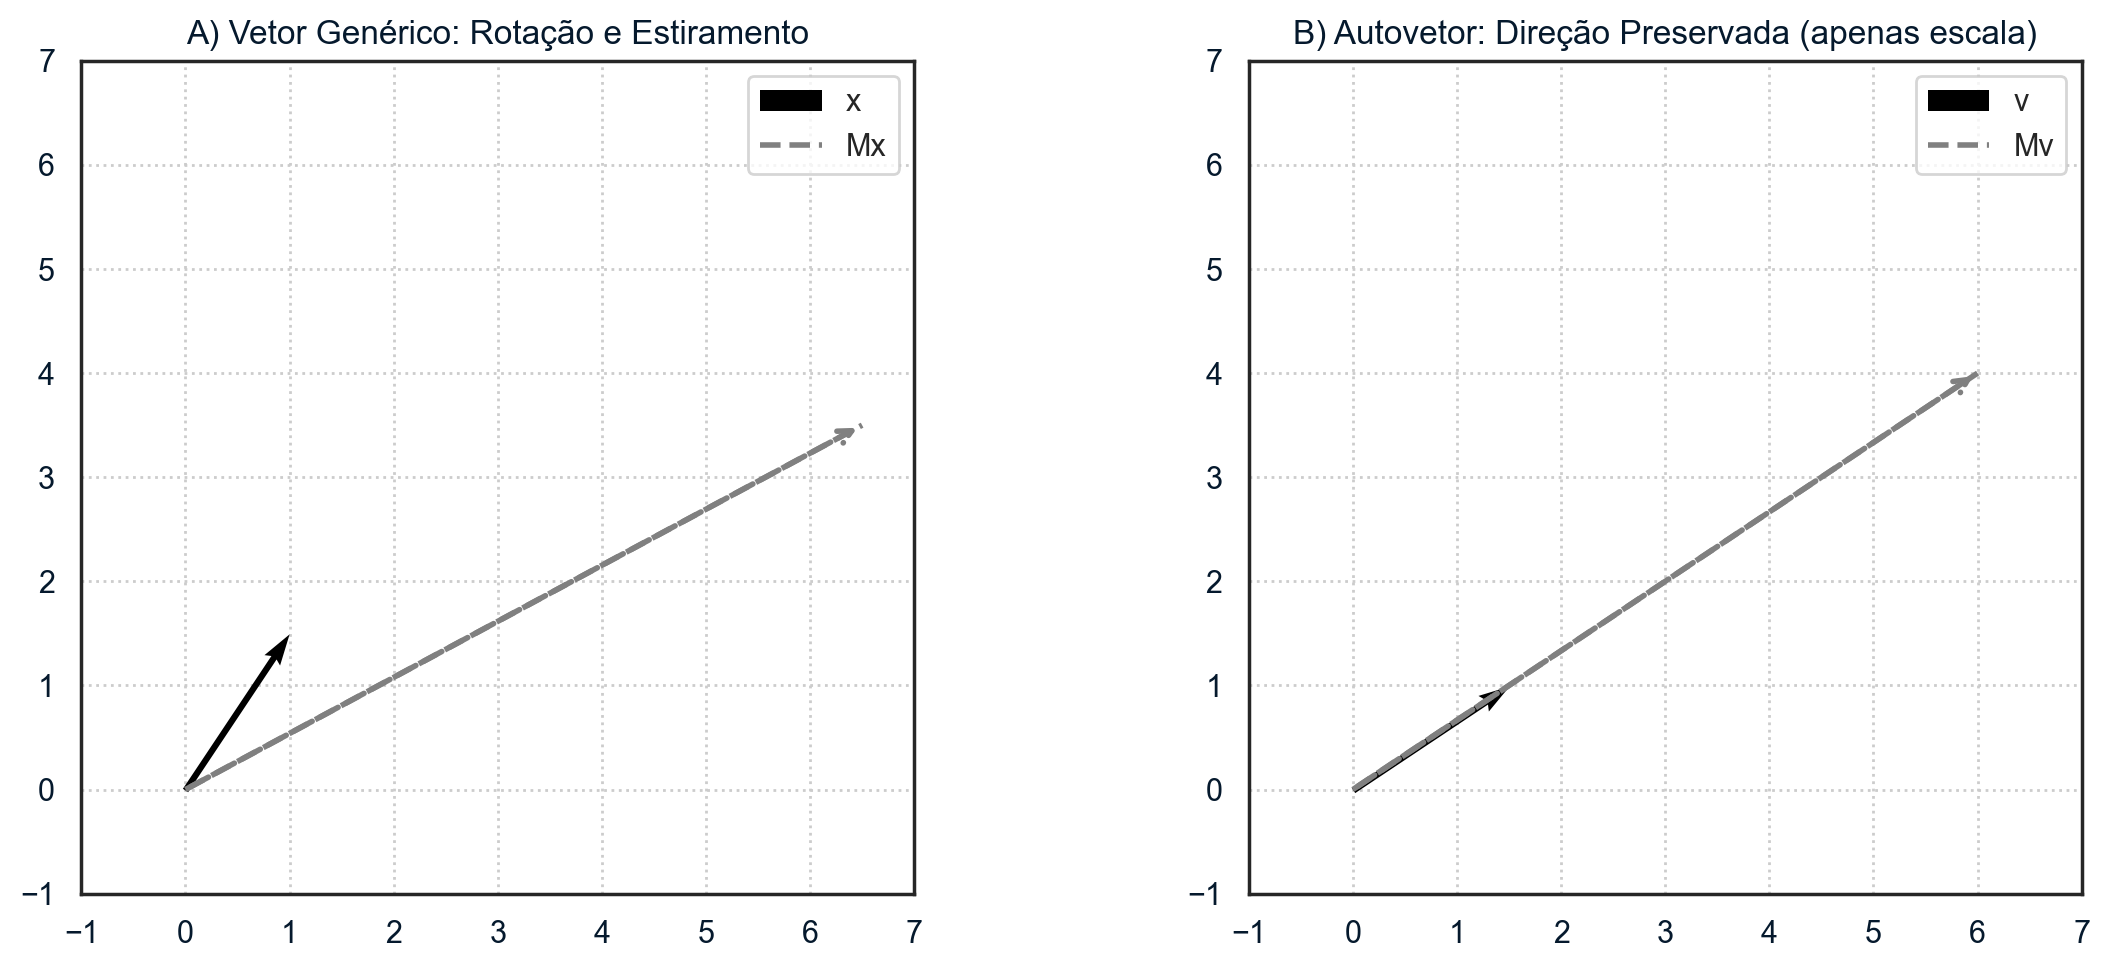

In [22]:
M = np.array([[2, 3], 
              [2, 1]])

# Vetor x comum
x = np.array([1, 1.5])
Mx = M @ x

# Vetor v (autovetor de M)
v = np.array([1.5, 1])
Mv = M @ v

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico A: Transformação genérica (rotação + escala) ---
axes[0].quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, 
               color='black', label='x')
# Traçado tracejado seguro para a legenda
axes[0].plot([0, Mx[0]], [0, Mx[1]], color='gray', linestyle='--', linewidth=2, label='Mx')
axes[0].annotate('', xy=(Mx[0], Mx[1]), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='gray', lw=2, ls='--'))

axes[0].set_xlim([-1, 7])
axes[0].set_ylim([-1, 7])
axes[0].grid(True, linestyle=":")
axes[0].legend()
axes[0].set_aspect('equal')
axes[0].set_title("A) Vetor Genérico: Rotação e Estiramento")

# --- Gráfico B: Autovetor (mantém a direção) ---
axes[1].quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, 
               color='black', label='v')
# Traçado tracejado seguro para a legenda
axes[1].plot([0, Mv[0]], [0, Mv[1]], color='gray', linestyle='--', linewidth=2, label='Mv')
axes[1].annotate('', xy=(Mv[0], Mv[1]), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='gray', lw=2, ls='--'))

axes[1].set_xlim([-1, 7])
axes[1].set_ylim([-1, 7])
axes[1].grid(True, linestyle=":")
axes[1].legend()
axes[1].set_aspect('equal')
axes[1].set_title("B) Autovetor: Direção Preservada (apenas escala)")

plt.tight_layout()
plt.show()

--- 
## 6. Transposição, Regra LIVE EVIL e Matrizes Simétricas

### Transposição
A transposição troca os índices de linha e coluna: $(A^T)_{i,j} = A_{j,i}$. A transposição dupla restaura a matriz: $(A^T)^T = A$.

### Regra LIVE EVIL
Ao transpor o produto de várias matrizes, transpõem-se os fatores e inverte-se a ordem de multiplicação:

$$(LIVE)^T = E^T V^T I^T L^T$$

### Matrizes Simétricas
Uma matriz é simétrica se $A = A^T$. Isso exige que ela seja obrigatoriamente quadrada.

Para **qualquer** matriz retangular $A \in \mathbb{R}^{M \times N}$:
* $A^T A$ é uma matriz quadrada simétrica de dimensão $N \times N$.
* $A A^T$ é uma matriz quadrada simétrica de dimensão $M \times M$.

**Demonstração:**
$$(A^T A)^T = A^T (A^T)^T = A^T A$$

Regra LIVE EVIL confere? True


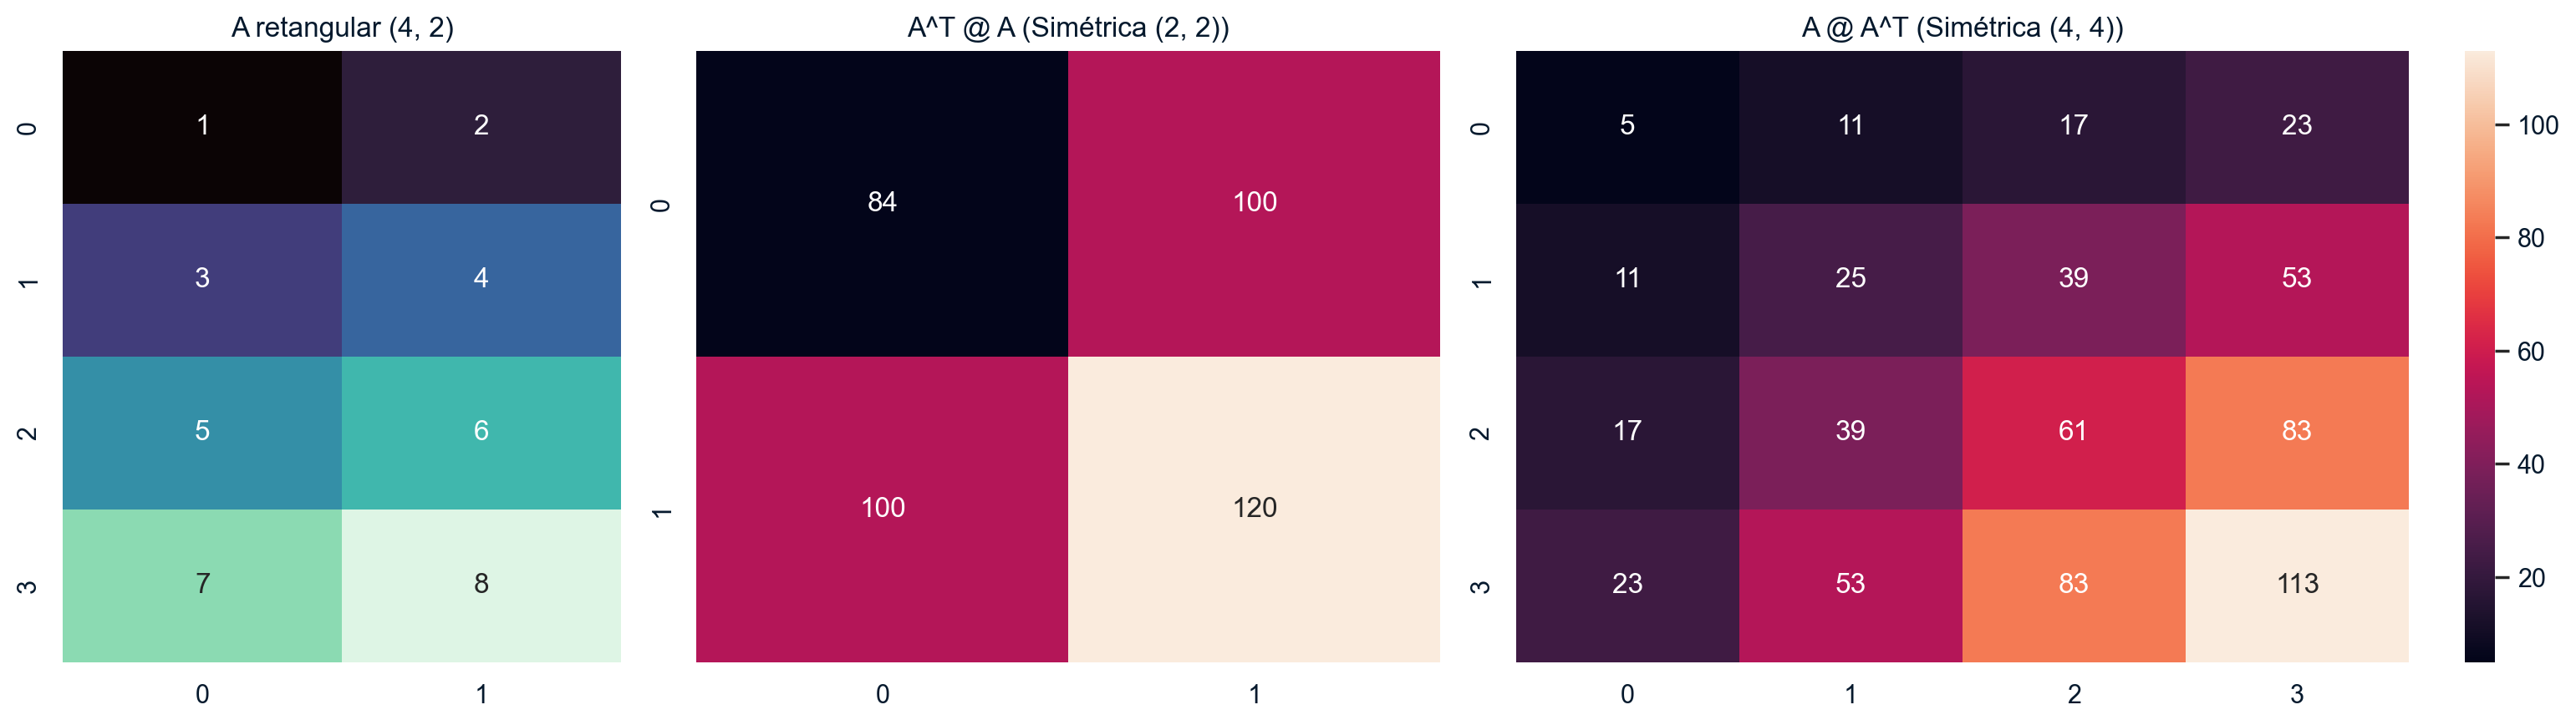

In [23]:
# Testando a regra LIVE EVIL
L = np.random.randn(3, 4)
I_mat = np.random.randn(4, 2)
V = np.random.randn(2, 5)
E = np.random.randn(5, 3)

res_esquerda = (L @ I_mat @ V @ E).T
res_direita = E.T @ V.T @ I_mat.T @ L.T

print("Regra LIVE EVIL confere?", np.allclose(res_esquerda, res_direita))

# Criando matrizes simétricas a partir de matriz retangular A (4x2)
A_rect = np.array([[1, 2],
                   [3, 4],
                   [5, 6],
                   [7, 8]])

AtA = A_rect.T @ A_rect  # 2x2
AAt = A_rect @ A_rect.T  # 4x4

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), gridspec_kw={'width_ratios': [1.5, 2, 3]})

sns.heatmap(A_rect, annot=True, fmt="d", cmap="mako", cbar=False, ax=axes[0])
axes[0].set_title(f"A retangular {A_rect.shape}")

sns.heatmap(AtA, annot=True, fmt="d", cmap="rocket", cbar=False, ax=axes[1])
axes[1].set_title(f"A^T @ A (Simétrica {AtA.shape})")

sns.heatmap(AAt, annot=True, fmt="d", cmap="rocket", cbar=True, ax=axes[2])
axes[2].set_title(f"A @ A^T (Simétrica {AAt.shape})")

plt.tight_layout()
plt.show()

--- 
## Resumo Geral das Operações em Matrizes

| Operação | Notação Matemática | Código NumPy | Condição de Dimensão |
| :--- | :--- | :--- | :--- |
| **Adição / Subtração** | $A \pm B$ | `A + B` ou `A - B` | Mesmas dimensões ($M \times N$) |
| **Multiplicação Escalar** | $\lambda A$ | `s * A` | Qualquer dimensão |
| **Deslocamento (*Shifting*)** | $A + \lambda I$ | `A + s * np.eye(len(A))` | Matrizes quadradas ($N \times N$) |
| **Produto de Hadamard** | $A \odot B$ | `A * B` | Mesmas dimensões ($M \times N$) |
| **Multiplicação Padrão** | $A B$ | `A @ B` | Dimensões internas concordantes ($(M \times N) \times (N \times K)$) |
| **Transposição** | $A^T$ | `A.T` ou `np.transpose(A)` | Troca $M \times N$ por $N \times M$ |
| **Matriz Simétrica** | $A^T A$ e $A A^T$ | `A.T @ A` e `A @ A.T` | Sempre quadradas e simétricas |